# Case Study C.7.1 — Collared Floater: Solution

Date: 2025-03-10 | Maturity: 5yr | Quarterly | Floor: 2% | Cap: 5%

A **collared floater** pays: $\max(K_{\text{floor}},\; \min(r,\; K_{\text{cap}}))$

Replicating portfolio:

| Instrument | Position |
|---|---|
| Floating-rate note | +1 |
| Floor (strike = 2%) | +1 |
| Cap (strike = 5%) | −1 |

In [1]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.optimize import fsolve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

curves = pd.read_excel('fiderivs_2025-03-10.xlsx', sheet_name='rate curves').set_index('tenor')

NOTIONAL = 100
T = 5
CPNFREQ = 4
dt = 1.0 / CPNFREQ
BOUND_LOWER = 0.02
BOUND_UPPER = 0.05

print('Rate Curves (2025-03-10):')
curves.style.format('{:.4f}').format_index('{:.2f}')

Rate Curves (2025-03-10):


,swap rates,spot rates,discounts,forwards,flat vols
tenor,,,,,
0.25,0.0422,0.0422,0.9896,nan,nan
0.50,0.0409,0.0409,0.9798,0.0397,0.1463
0.75,0.0398,0.0397,0.9708,0.0374,0.1686
1.00,0.0388,0.0388,0.9621,0.0360,0.1908
1.25,0.0379,0.0378,0.9540,0.0339,0.2219
1.50,0.0372,0.0372,0.9460,0.0339,0.2450
1.75,0.0368,0.0368,0.9380,0.0343,0.2614
2.00,0.0366,0.0365,0.9299,0.0348,0.2722
2.25,0.0363,0.0362,0.9221,0.0339,0.2786


## Helper Functions

In [2]:
def get_discount(t, spot_shift=0.0):
    """Discount factor Z(0,t) from quarterly-compounded spot rates."""
    tenors = curves.index.values
    spots = curves['spot rates'].values + spot_shift
    discounts = (1 + spots / CPNFREQ) ** (-tenors * CPNFREQ)
    return np.interp(t, tenors, discounts)

def get_forward(t1, t2, spot_shift=0.0):
    """Quarterly-compounded forward rate from t1 to t2."""
    Z1 = get_discount(t1, spot_shift)
    Z2 = get_discount(t2, spot_shift)
    tau = t2 - t1
    return CPNFREQ * ((Z1 / Z2) ** (1 / (tau * CPNFREQ)) - 1)

def black_caplet(F, K, sigma, t_fix, t_pay, spot_shift=0.0):
    Z = get_discount(t_pay, spot_shift)
    tau = t_pay - t_fix
    if t_fix <= 0 or sigma <= 0:
        return Z * tau * max(F - K, 0)
    d1 = (np.log(F/K) + 0.5*sigma**2*t_fix) / (sigma*np.sqrt(t_fix))
    d2 = d1 - sigma * np.sqrt(t_fix)
    return Z * tau * (F * norm.cdf(d1) - K * norm.cdf(d2))

def black_floorlet(F, K, sigma, t_fix, t_pay, spot_shift=0.0):
    Z = get_discount(t_pay, spot_shift)
    tau = t_pay - t_fix
    if t_fix <= 0 or sigma <= 0:
        return Z * tau * max(K - F, 0)
    d1 = (np.log(F/K) + 0.5*sigma**2*t_fix) / (sigma*np.sqrt(t_fix))
    d2 = d1 - sigma * np.sqrt(t_fix)
    return Z * tau * (K * norm.cdf(-d2) - F * norm.cdf(-d1))

def price_cap(K, vol, spot_shift=0.0):
    return NOTIONAL * sum(
        black_caplet(get_forward((i-1)*dt, i*dt, spot_shift), K, vol, (i-1)*dt, i*dt, spot_shift)
        for i in range(1, int(T*CPNFREQ)+1))

def price_floor(K, vol, spot_shift=0.0):
    return NOTIONAL * sum(
        black_floorlet(get_forward((i-1)*dt, i*dt, spot_shift), K, vol, (i-1)*dt, i*dt, spot_shift)
        for i in range(1, int(T*CPNFREQ)+1))

def price_collared_floater(spot_shift=0.0):
    vol = np.interp(T, curves.index, curves['flat vols'])
    floater = NOTIONAL   # par floater always = par
    floor_v = price_floor(BOUND_LOWER, vol, spot_shift)
    cap_v   = price_cap(BOUND_UPPER,   vol, spot_shift)
    return floater, floor_v, cap_v, floater + floor_v - cap_v

---
## 1. Pricing the Components

### 1.1 Floater Value

In [3]:
print('A par floater (no credit spread) resets to par at every coupon date.')
print(f'Floater value = {NOTIONAL:.2f}')

A par floater (no credit spread) resets to par at every coupon date.
Floater value = 100.00


### 1.2 Floor and Cap Prices

In [4]:
flat_vol_5y = np.interp(T, curves.index, curves['flat vols'])
floor_price = price_floor(BOUND_LOWER, flat_vol_5y)
cap_price   = price_cap(BOUND_UPPER,   flat_vol_5y)

print(f'Flat vol at 5yr tenor:   {flat_vol_5y*100:.4f}%')
print(f'Floor (strike = 2%):     {floor_price:.4f}')
print(f'Cap   (strike = 5%):     {cap_price:.4f}')

Flat vol at 5yr tenor:   28.0916%
Floor (strike = 2%):     0.7397
Cap   (strike = 5%):     0.9773


The floor and cap are priced as sums of Black floorlets/caplets. Each period, the forward rate and flat vol determine the option value, discounted to today.

### 1.3 Portfolio Value

In [5]:
floater, floor_v, cap_v, portfolio = price_collared_floater()

print(f'+1 Floater:          {floater:.4f}')
print(f'+1 Floor (2%):      +{floor_v:.4f}')
print(f'-1 Cap  (5%):       -{cap_v:.4f}')
print(f'{"─"*35}')
print(f'Total Portfolio:     {portfolio:.4f}')
print()
print('The portfolio trades BELOW par (100).')
print('Why: The 5% cap (which we sell) is worth MORE than the 2% floor')
print('(which we buy). At current rates ~3.7%, the cap is closer to ATM')
print('than the floor, making it more expensive. Net premium is negative.')

+1 Floater:          100.0000
+1 Floor (2%):      +0.7397
-1 Cap  (5%):       -0.9773
───────────────────────────────────
Total Portfolio:     99.7624

The portfolio trades BELOW par (100).
Why: The 5% cap (which we sell) is worth MORE than the 2% floor
(which we buy). At current rates ~3.7%, the cap is closer to ATM
than the floor, making it more expensive. Net premium is negative.


---
## 2. Risk Analysis

### 2.1 Duration

In [6]:
shock = 0.0001  # 1bp

def num_duration(fn):
    p0   = fn(0)
    p_up = fn(+shock)
    p_dn = fn(-shock)
    return -(p_up - p_dn) / (2 * shock * p0)

flat_vol_5y = np.interp(T, curves.index, curves['flat vols'])

dur_floater   = num_duration(lambda s: NOTIONAL)
dur_floor     = num_duration(lambda s: price_floor(BOUND_LOWER, flat_vol_5y, s))
dur_cap       = num_duration(lambda s: price_cap(BOUND_UPPER,   flat_vol_5y, s))
dur_portfolio = num_duration(lambda s: price_collared_floater(s)[3])

print(f'{"Component":<22} {"Duration (yrs)":>14}')
print('─'*38)
print(f'{"Floater":<22} {dur_floater:>14.4f}')
print(f'{"Floor (2%)":<22} {dur_floor:>14.4f}')
print(f'{"Cap  (5%) [short]":<22} {-dur_cap:>14.4f}   (short position)')
print(f'{"Portfolio":<22} {dur_portfolio:>14.4f}')
print()
print('• Floater: ~0 duration — resets quarterly, so rate sensitivity is minimal.')
print('• Floor: negative duration — rises in value when rates fall (like a put on rates).')
print('• Cap (short): we sold it, so rising rates hurt less (reduces positive cap delta).')
print('• Portfolio: modest positive duration ~1.3yrs, much less than a fixed-rate bond.')

Component              Duration (yrs)
──────────────────────────────────────
Floater                        0.0000
Floor (2%)                    34.5531
Cap  (5%) [short]            109.6541   (short position)
Portfolio                      1.3304

• Floater: ~0 duration — resets quarterly, so rate sensitivity is minimal.
• Floor: negative duration — rises in value when rates fall (like a put on rates).
• Cap (short): we sold it, so rising rates hurt less (reduces positive cap delta).
• Portfolio: modest positive duration ~1.3yrs, much less than a fixed-rate bond.


### 2.2 OAS

In [7]:
TARGET = 100.0
oas = fsolve(lambda s: price_collared_floater(s[0])[3] - TARGET, x0=0.001)[0]

print(f'Portfolio value at base:  {portfolio:.4f}')
print(f'Target (par):             {TARGET:.4f}')
print(f'OAS:                      {oas*10000:.2f} bps')
print()
print(f'A negative OAS of {abs(oas)*10000:.1f}bps means: if we assume the market prices')
print(f'this note at par, there is an implied spread of {abs(oas)*10000:.1f}bps that')
print(f'justifies the discount. Equivalently, the note offers a yield pickup')
print(f'of ~{abs(oas)*10000:.1f}bps over the SOFR curve in exchange for the collar.')

Portfolio value at base:  99.7624
Target (par):             100.0000
OAS:                      -18.50 bps

A negative OAS of 18.5bps means: if we assume the market prices
this note at par, there is an implied spread of 18.5bps that
justifies the discount. Equivalently, the note offers a yield pickup
of ~18.5bps over the SOFR curve in exchange for the collar.


### 2.3 Rate Scenario Analysis

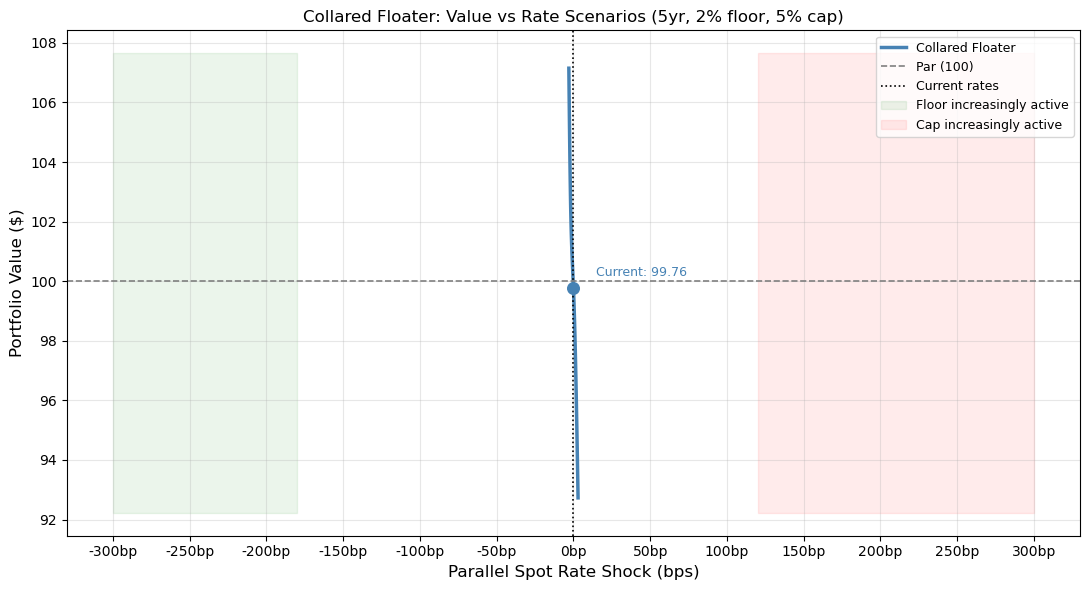

Convexity observations:
• LARGE rate drops (−200 to −300bp): floor kicks in → value rises sharply = POSITIVE convexity
• LARGE rate rises (+150 to +300bp): cap kicks in → coupon capped → value flattens = NEGATIVE convexity
• NEAR current rates: slope is gently positive (portfolio duration ~1.3yr)
• The asymmetry is the key feature: protection on the downside, limited upside


In [8]:
shocks = np.linspace(-0.03, 0.03, 121)
port_values = [price_collared_floater(s)[3] for s in shocks]

fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(shocks*100, port_values, color='steelblue', lw=2.5, label='Collared Floater')
ax.axhline(NOTIONAL, color='gray', ls='--', lw=1.2, label='Par (100)')
ax.axvline(0, color='black', ls=':', lw=1.2, label='Current rates')

ax.scatter([0], [portfolio], color='steelblue', zorder=5, s=70)
ax.annotate(f'Current: {portfolio:.2f}', xy=(0, portfolio),
            xytext=(15, portfolio+0.4), fontsize=9, color='steelblue')

ax.fill_betweenx([min(port_values)-0.5, max(port_values)+0.5],
                 -300, -180, alpha=0.08, color='green', label='Floor increasingly active')
ax.fill_betweenx([min(port_values)-0.5, max(port_values)+0.5],
                 120, 300, alpha=0.08, color='red', label='Cap increasingly active')

ax.set_xlabel('Parallel Spot Rate Shock (bps)', fontsize=12)
ax.set_ylabel('Portfolio Value ($)', fontsize=12)
ax.set_title('Collared Floater: Value vs Rate Scenarios (5yr, 2% floor, 5% cap)', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
ax.set_xticks(range(-300, 301, 50))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}bp'))
plt.tight_layout()
plt.show()

print('Convexity observations:')
print('• LARGE rate drops (−200 to −300bp): floor kicks in → value rises sharply = POSITIVE convexity')
print('• LARGE rate rises (+150 to +300bp): cap kicks in → coupon capped → value flattens = NEGATIVE convexity')
print('• NEAR current rates: slope is gently positive (portfolio duration ~1.3yr)')
print('• The asymmetry is the key feature: protection on the downside, limited upside')

---
## 3. Stress Test: +300bp Shock

### 3.1 Portfolio Value After +300bp

In [9]:
_, _, _, port_shocked = price_collared_floater(+0.03)
loss_pct = (port_shocked - portfolio) / portfolio * 100

print(f'Base portfolio value:      {portfolio:.4f}')
print(f'After +300bp shock:        {port_shocked:.4f}')
print(f'Dollar loss:              {port_shocked-portfolio:.4f}')
print(f'Percentage loss:          {loss_pct:.2f}%')
print()
print('With rates rising sharply, the cap we sold becomes deeply in-the-money')
print('(costs us more to unwind), while the floor we own becomes worthless.')
print('The net effect is a ~7% loss on the portfolio.')

Base portfolio value:      99.7624
After +300bp shock:        92.7274
Dollar loss:              -7.0350
Percentage loss:          -7.05%

With rates rising sharply, the cap we sold becomes deeply in-the-money
(costs us more to unwind), while the floor we own becomes worthless.
The net effect is a ~7% loss on the portfolio.


### 3.2 Orange County Comparison

In [10]:
leverage = 2.5
leveraged_loss = loss_pct * leverage

print(f'Unlevered loss:             {loss_pct:.2f}%')
print(f'Leveraged loss (2.5×):      {leveraged_loss:.2f}%')
print(f'Orange County actual loss:  22.3%')
print(f'Gap:                        {22.3 - abs(leveraged_loss):.1f} percentage points')
print()
print('Why the gap is so large:')
print('1. INSTRUMENT TYPE: OC held primarily inverse floaters with embedded leverage')
print('   (coupon = Fixed − Multiplier × Float). A 2× multiplier means each 1bp rate')
print('   rise costs 2bp of coupon — far worse than a collared floater.')
print('2. DURATION: OC had much longer effective duration instruments (~5–7yr).')
print('3. CONCENTRATION: $20bn pool, no diversification across rate scenarios.')
print('4. LIQUIDITY: Forced liquidation at distressed prices amplified losses.')
print('5. Our collared floater has a 5% cap as built-in protection — OC had none.')

Unlevered loss:             -7.05%
Leveraged loss (2.5×):      -17.63%
Orange County actual loss:  22.3%
Gap:                        4.7 percentage points

Why the gap is so large:
1. INSTRUMENT TYPE: OC held primarily inverse floaters with embedded leverage
   (coupon = Fixed − Multiplier × Float). A 2× multiplier means each 1bp rate
   rise costs 2bp of coupon — far worse than a collared floater.
2. DURATION: OC had much longer effective duration instruments (~5–7yr).
3. CONCENTRATION: $20bn pool, no diversification across rate scenarios.
4. LIQUIDITY: Forced liquidation at distressed prices amplified losses.
5. Our collared floater has a 5% cap as built-in protection — OC had none.


---
## 4. Optional: Volatility Skew (SABR)

### 4.1 SABR Implied Vols

In [11]:
def sabr_vol(F, K, T, alpha, beta, nu, rho):
    if abs(F - K) < 1e-10:
        term1 = alpha / (F**(1-beta))
        term2 = 1 + ((1-beta)**2/24*alpha**2/F**(2-2*beta)
                     + rho*beta*nu*alpha/(4*F**(1-beta))
                     + (2-3*rho**2)/24*nu**2) * T
        return term1 * term2
    log_FK = np.log(F/K)
    FK_mid = np.sqrt(F*K)
    z = nu/alpha * FK_mid**(1-beta) * log_FK
    x_z = np.log((np.sqrt(1-2*rho*z+z**2)+z-rho)/(1-rho))
    A = alpha / (FK_mid**(1-beta) * (1+(1-beta)**2/24*log_FK**2+(1-beta)**4/1920*log_FK**4))
    B = z / x_z
    C = 1 + ((1-beta)**2/24*alpha**2/FK_mid**(2-2*beta)
             + rho*beta*nu*alpha/(4*FK_mid**(1-beta))
             + (2-3*rho**2)/24*nu**2) * T
    return A * B * C

# SABR parameters
beta, alpha_s, nu, rho = 0.25, 0.0214, 0.60, -0.20
F_5y = sum(get_forward((i-1)*dt, i*dt) * dt for i in range(1, int(T*CPNFREQ)+1)) / (T)
# Use last forward as proxy
F_5y = get_forward(4.75, 5.0)

sabr_vol_floor = sabr_vol(F_5y, BOUND_LOWER, T, alpha_s, beta, nu, rho)
sabr_vol_cap   = sabr_vol(F_5y, BOUND_UPPER, T, alpha_s, beta, nu, rho)
flat_vol_5y    = np.interp(T, curves.index, curves['flat vols'])

print(f'5yr forward rate (F):   {F_5y*100:.4f}%')
print(f'SABR: β={beta}, α={alpha_s}, ν={nu}, ρ={rho}')
print()
print(f'{"":22} {"Flat Vol":>10} {"SABR Vol":>10}')
print('─'*44)
print(f'{"Floor (K=2%, below F)":22} {flat_vol_5y*100:>9.4f}% {sabr_vol_floor*100:>9.4f}%')
print(f'{"Cap   (K=5%, above F)":22} {flat_vol_5y*100:>9.4f}% {sabr_vol_cap*100:>9.4f}%')

5yr forward rate (F):   3.7200%
SABR: β=0.25, α=0.0214, ν=0.6, ρ=-0.2

                         Flat Vol   SABR Vol
────────────────────────────────────────────
Floor (K=2%, below F)    28.0916%   45.1287%
Cap   (K=5%, above F)    28.0916%   26.2240%


### 4.2 Re-pricing with SABR Skew

In [12]:
floor_flat  = price_floor(BOUND_LOWER, flat_vol_5y)
cap_flat    = price_cap(BOUND_UPPER,   flat_vol_5y)
port_flat   = NOTIONAL + floor_flat - cap_flat

floor_sabr  = price_floor(BOUND_LOWER, sabr_vol_floor)
cap_sabr    = price_cap(BOUND_UPPER,   sabr_vol_cap)
port_sabr   = NOTIONAL + floor_sabr - cap_sabr

print(f'{"":18} {"Flat-Vol":>10} {"SABR":>10} {"Δ":>10}')
print('─'*50)
print(f'{"Floor price":18} {floor_flat:>10.4f} {floor_sabr:>10.4f} {floor_sabr-floor_flat:>+10.4f}')
print(f'{"Cap price":18} {cap_flat:>10.4f} {cap_sabr:>10.4f} {cap_sabr-cap_flat:>+10.4f}')
print(f'{"Portfolio":18} {port_flat:>10.4f} {port_sabr:>10.4f} {port_sabr-port_flat:>+10.4f}')
print()
print('Interpretation:')
print(f'• ρ = {rho} (negative) → LEFT skew → higher vol at lower strikes')
print(f'• Floor (K=2% < F): SABR vol rises to {sabr_vol_floor*100:.1f}% → floor much more expensive')
print(f'• Cap  (K=5% > F): SABR vol falls to {sabr_vol_cap*100:.1f}% → cap slightly cheaper')
print(f'• Net effect: SABR portfolio ({port_sabr:.4f}) > Flat-vol ({port_flat:.4f})')
print(f'  The negative skew benefits the holder of a collared floater.')

                     Flat-Vol       SABR          Δ
──────────────────────────────────────────────────
Floor price            0.7397     1.3827    +0.6430
Cap price              0.9773     0.8402    -0.1371
Portfolio             99.7624   100.5425    +0.7801

Interpretation:
• ρ = -0.2 (negative) → LEFT skew → higher vol at lower strikes
• Floor (K=2% < F): SABR vol rises to 45.1% → floor much more expensive
• Cap  (K=5% > F): SABR vol falls to 26.2% → cap slightly cheaper
• Net effect: SABR portfolio (100.5425) > Flat-vol (99.7624)
  The negative skew benefits the holder of a collared floater.
